In [2]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from matplotlib import font_manager, rc


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

import lightgbm
import catboost
import warnings

warnings.filterwarnings('ignore', category=UserWarning)


SEED = 2025 
np.random.seed(SEED)
plt.rc('font', family='NanumGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')
print("--- 라이브러리 로드 완료 ---")

--- 라이브러리 로드 완료 ---


In [4]:
# 1. 데이터 로드 및 타겟 변수(y) 생성
print("---데이터 로드 및 타겟 변수 생성 ---")
file_path = '../output/results/df_analysis.parquet'
try:
    df_analysis = pd.read_parquet(file_path)
    print(f"  - 데이터셋 로드 완료 (Shape: {df_analysis.shape})")
except Exception as e:
    print(f"  - 오류 발생: {e}. 데이터 파일 경로를 확인하세요.")

# 종속 변수(y) 생성: AI 제안 수락 여부 (0: 실행, 1: 선택)
# 학습 데이터와 타겟 간의 데이터 누수(Data Leakage)를 방지하기 위해 
# event_name 기반으로 y를 생성한 후 관련 컬럼은 제거할 예정입니다.
df_analysis['is_selected'] = np.where(df_analysis['event_name'].str.startswith('run_'), 0, 1)

print(f"  - 타겟 변수 'is_selected' 생성 완료 (Class Ratio)")
display(df_analysis['is_selected'].value_counts(normalize=True))

---데이터 로드 및 타겟 변수 생성 ---
  - 데이터셋 로드 완료 (Shape: (57814, 19))
  - 타겟 변수 'is_selected' 생성 완료 (Class Ratio)


is_selected
0    0.627305
1    0.372695
Name: proportion, dtype: float64

In [7]:
# 2. 독립 변수(X) 및 종속 변수(y) 분리
print("\n--- 피처(X) 및 타겟(y) 분리 ---")

y = df_analysis['is_selected']

# 학습 시 제외할 컬럼 리스트 (식별자, 타겟 직접 연관 변수, 데이터 누수 가능성 있는 변수)
features_to_drop = [
    'distinct_id', 'user_id', 'time',        # 1. 식별자 및 시간 정보
    'is_selected',                           # 2. 타겟 변수 본인
    'event_name',                            # 3. 타겟 변수 생성 근거
    'response_time_ms', 'input_sentence_length', 
    'selected_sentence_id', 'index'          # 4. 데이터 누수(Leakage) 방지 컬럼
]

existing_features_to_drop = [col for col in features_to_drop if col in df_analysis.columns]
X = df_analysis.drop(columns=existing_features_to_drop)

print(f"  - 독립 변수(X) 준비 완료 (Shape: {X.shape})")
print(f"  - 최종 학습 피처 리스트: {X.columns.tolist()}")


--- 피처(X) 및 타겟(y) 분리 ---
  - 독립 변수(X) 준비 완료 (Shape: (57814, 11))
  - 최종 학습 피처 리스트: ['is_logged_in_event', 'is_logged_in_user', 'llm_name', 'llm_provider', 'llm_version', 'field', 'maintenance', 'tone', 'position', 'trigger', 'initial_referring_domain_user']


In [8]:
# 3. 데이터 전처리 파이프라인 구성
print("\n--- 데이터 타입별 전처리 계획 수립 ---")

# 1. 수치형 피처(Numerical Features) 분류
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'is_logged_in_user' in numeric_features:
    numeric_features.remove('is_logged_in_user')

# 2. 범주형 피처(Categorical Features) 분류
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
if 'is_logged_in_user' not in categorical_features:
    categorical_features.append('is_logged_in_user')

print(f"  - [확인] 수치형 피처 리스트: {numeric_features}") # 데이터셋 특성에 따라 빈 리스트일 수 있음
print(f"  - [확인] 범주형 피처 리스트: {categorical_features}")

# 3. 수치형 데이터 전처리: 결측치 중앙값 대체 및 스케일링
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. 범주형 데이터 전처리: 결측치 최빈값 대체 및 원-핫 인코딩
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('to_string', FunctionTransformer(lambda x: x.astype(str))), # 형변환 안전성 확보
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5. ColumnTransformer를 통한 전처리 통합
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)
print("  - ColumnTransformer 전처리 파이프라인 정의 완료")


--- 데이터 타입별 전처리 계획 수립 ---
  - [확인] 수치형 피처 리스트: []
  - [확인] 범주형 피처 리스트: ['is_logged_in_event', 'llm_name', 'llm_provider', 'llm_version', 'field', 'maintenance', 'tone', 'position', 'trigger', 'initial_referring_domain_user', 'is_logged_in_user']
  - ColumnTransformer 전처리 파이프라인 정의 완료


In [10]:
# 4. 학습/테스트 데이터 분할 및 모델 파이프라인 정의
print("\n--- 데이터 분할 및 모델 파이프라인 정의 ---")

# Stratified Sampling을 사용하여 클래스 비율을 유지하며 8:2로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"  - 훈련 데이터(X_train): {X_train.shape}")
print(f"  - 테스트 데이터(X_test): {X_test.shape}")

# RandomForest 분류기 정의 (과적합 방지 및 클래스 불균형 처리를 위한 파라미터 설정)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=SEED, 
        n_jobs=-1,              # 멀티 프로세싱 활성화
        max_depth=10,           # 모델 복잡도 제한 (과적합 방지)
        class_weight='balanced' # 타겟 클래스 불균형 보정
    )) 
])
print("  - 전처리 및 분류 모델 파이프라인 구성 완료")


--- 데이터 분할 및 모델 파이프라인 정의 ---
  - 훈련 데이터(X_train): (46251, 11)
  - 테스트 데이터(X_test): (11563, 11)
  - 전처리 및 분류 모델 파이프라인 구성 완료


In [11]:
# 5. 모델 학습 및 성능 검증
print("\n--- 모델 학습 및 성능 평가 ---")

print("  - RandomForest 모델 학습을 시작합니다...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()
print(f"  - 학습 완료 (소요 시간: {end_time - start_time:.2f}초)")

y_pred = model.predict(X_test)

print("\n" + "="*50)
print("🏆 분류 성능 평가 지표 (Classification Report)")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['0: 실행', '1: 선택']))


--- 모델 학습 및 성능 평가 ---
  - RandomForest 모델 학습을 시작합니다...
  - 학습 완료 (소요 시간: 2.07초)

🏆 분류 성능 평가 지표 (Classification Report)
              precision    recall  f1-score   support

       0: 실행       0.92      0.67      0.78      7254
       1: 선택       0.62      0.90      0.74      4309

    accuracy                           0.76     11563
   macro avg       0.77      0.79      0.76     11563
weighted avg       0.81      0.76      0.76     11563



In [51]:
#  훈련/테스트 분리 및 "AI 수사관" 모델 정의
print("\n--- [4/9] 훈련/테스트 분리 및 'AI 수사관' 모델 정의 ---")

# 1. 훈련용(80%)과 테스트용(20%) 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f"  - 훈련 데이터(X_train): {X_train.shape}")
print(f"  - 테스트 데이터(X_test): {X_test.shape}")

# 2. "AI 수사관" 모델 정의 (Random Forest)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=SEED, 
        n_jobs=-1,          # (모든 CPU 사용)
        max_depth=10,       # (너무 깊지 않게, 과적합 방지)
        class_weight='balanced' # (y=0(70%)과 y=1(30%)의 불균형 처리)
    )) 
])
print("  - 모델 파이프라인 정의 완료.")


--- [4/9] 훈련/테스트 분리 및 'AI 수사관' 모델 정의 ---
  - 훈련 데이터(X_train): (46251, 11)
  - 테스트 데이터(X_test): (11563, 11)
  - 모델 파이프라인 정의 완료.


In [52]:
# "예측" (Prediction) - 모델 훈련 및 "진짜" 성능 평가
print("\n--- [5/9] '예측' (Prediction) - 모델 훈련 및 '진짜' 성능 평가 ---")

# 1. 훈련 (컨닝이 없으므로 1~3초면 충분합니다)
print("  - 'AI 수사관'이 '진짜' 훈련을 시작합니다...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()
print(f"  - 훈련 완료! (소요 시간: {end_time - start_time:.2f} 초)")

# 2. 예측 (테스트 데이터)
y_pred = model.predict(X_test)

# 3. 평가
print("\n" + "="*50)
print("🏆 [예측 성능 평가] (Classification Report)")
print("="*50)
# (이제 'Accuracy'가 1.00이 아닌, '현실적인' 70~80%대 점수가 나와야 합니다!)
print(classification_report(y_test, y_pred, target_names=['0: 실행', '1: 선택']))


--- [5/9] '예측' (Prediction) - 모델 훈련 및 '진짜' 성능 평가 ---
  - 'AI 수사관'이 '진짜' 훈련을 시작합니다...
  - 훈련 완료! (소요 시간: 0.94 초)

🏆 [예측 성능 평가] (Classification Report)
              precision    recall  f1-score   support

       0: 실행       0.92      0.67      0.78      7254
       1: 선택       0.62      0.90      0.74      4309

    accuracy                           0.76     11563
   macro avg       0.77      0.79      0.76     11563
weighted avg       0.81      0.76      0.76     11563




--- 피처 중요도 분석 및 시각화 ---

🏆 주요 피처 그룹별 중요도 상위 10개 (Feature Group Importance)


Feature_Group
llm            0.378696
position       0.163414
trigger        0.148952
initial        0.129412
maintenance    0.064591
field          0.052325
is             0.035157
tone           0.027454
Name: Importance, dtype: float64


  - [시각화] 피처 중요도 그래프 생성 중...
  - 'feature_importance.png' 파일 저장 완료


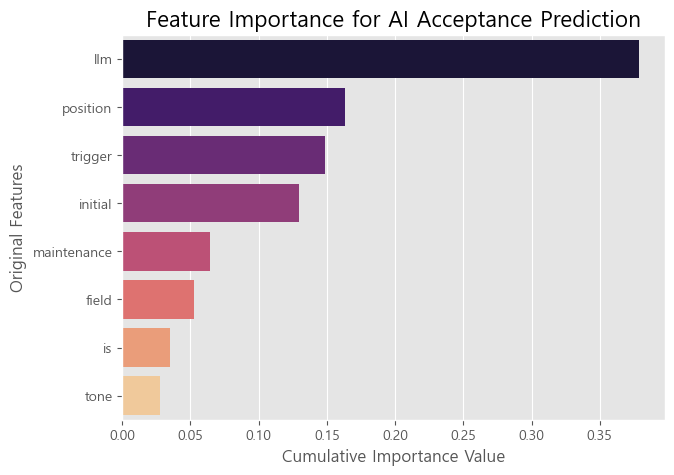

In [12]:
# 6. 피처 중요도(Feature Importance) 추출 및 분석
print("\n--- 피처 중요도 분석 및 시각화 ---")

try:
    # 파이프라인 내 학습된 분류기 및 전처리 객체 추출
    preprocessor = model.named_steps['preprocessor']
    classifier = model.named_steps['classifier']

    # OneHotEncoding을 통해 생성된 범주형 피처의 이름을 추출
    cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)
    
    # 수치형 피처와 범주형 피처 이름을 통합하여 전체 리스트 생성
    if not numeric_features:
        all_feature_names = list(cat_features)
    else:
        all_feature_names = list(numeric_features) + list(cat_features)
        
    # 모델의 피처 중요도 데이터프레임 생성
    importances = classifier.feature_importances_
    df_importance = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    
    # 원본 피처 그룹별로 중요도 합산 (예: tone_친절함, tone_전문적 -> tone 그룹으로 통합)
    df_importance_grouped = df_importance.copy()
    df_importance_grouped['Feature_Group'] = df_importance_grouped['Feature'].apply(lambda x: x.split('_')[0]) 
    df_importance_summary = df_importance_grouped.groupby('Feature_Group')['Importance'].sum().sort_values(ascending=False)
    
    print("\n" + "="*50)
    print("🏆 주요 피처 그룹별 중요도 상위 10개 (Feature Group Importance)")
    print("="*50)
    display(df_importance_summary.head(10))
    
    # 시각화: 수평 바 차트 생성
    print("\n  - [시각화] 피처 중요도 그래프 생성 중...")
    plt.figure(figsize=(7, 5))
    sns.barplot(
        x=df_importance_summary.head(10).values, 
        y=df_importance_summary.head(10).index,
        palette='magma'
    )
    plt.title('Feature Importance for AI Acceptance Prediction', fontsize=16)
    plt.xlabel('Cumulative Importance Value', fontsize=12)
    plt.ylabel('Original Features', fontsize=12)
    plt.savefig('../output/images/feature_importance.png')
    print("  - 'feature_importance.png' 파일 저장 완료")
    plt.show()

except Exception as e:
    print(f"  - ⚠️ 피처 중요도 분석 중 오류 발생: {e}")

In [13]:
# 7. 성능 고도화를 위한 다양한 모델(LGBM, CatBoost) 추가 및 비교
print("\n--- [7/9] 모델별 성능 비교 분석 (Baseline vs Boosting) ---")

# 하이퍼파라미터 및 클래스 가중치 설정
models = {
    'RandomForest': RandomForestClassifier(random_state=SEED, n_jobs=-1, max_depth=10, class_weight='balanced'),
    'LightGBM': LGBMClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'),
    'CatBoost': CatBoostClassifier(random_state=SEED, verbose=0, class_weights={0: 0.627, 1: 0.373}) # 클래스 비율 반영
}

results = {}

for name, classifier in models.items():
    print(f"\n--- [{name}] 모델 학습 및 평가 시작 ---")
    
    # 통합 파이프라인 구성
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # 모델 학습
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    end_time = time.time()
    print(f"  - 학습 완료 (소요 시간: {end_time - start_time:.2f}초)")
    
    # 예측 및 메트릭 산출
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['0: 실행', '1: 선택'], output_dict=True)
    
    results[name] = {
        'accuracy': accuracy,
        'report': report,
        'pipeline': pipeline 
    }
    
    print(f"  - [{name}] 성능 요약:")
    print(classification_report(y_test, y_pred, target_names=['0: 실행', '1: 선택']))

# 모델별 최종 성능 요약 출력
print("\n" + "="*50)
print("🏆 모델별 최종 성능 요약 (Model Comparison)")
print("="*50)
for name, res in results.items():
    print(f"  - [{name}] Accuracy: {res['accuracy']:.4f} | F1-Score(1): {res['report']['1: 선택']['f1-score']:.4f}")
    print(f"    (Precision: {res['report']['1: 선택']['precision']:.4f}, Recall: {res['report']['1: 선택']['recall']:.4f})")
print("="*50)


--- [7/9] 모델별 성능 비교 분석 (Baseline vs Boosting) ---

--- [RandomForest] 모델 학습 및 평가 시작 ---
  - 학습 완료 (소요 시간: 2.97초)
  - [RandomForest] 성능 요약:
              precision    recall  f1-score   support

       0: 실행       0.92      0.67      0.78      7254
       1: 선택       0.62      0.90      0.74      4309

    accuracy                           0.76     11563
   macro avg       0.77      0.79      0.76     11563
weighted avg       0.81      0.76      0.76     11563


--- [LightGBM] 모델 학습 및 평가 시작 ---
[LightGBM] [Info] Number of positive: 17238, number of negative: 29013
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 118
[LightGBM] [Info] Number of data points in the train set: 46251, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000

In [14]:
# 8. 앙상블(Ensemble) 모델 구축 - Voting Classifier
print("\n--- 모델 앙상블(Soft Voting) 수행 ---")

# 앙상블에 참여할 개별 모델 파이프라인 구성
estimators = []
for name, res in results.items():
    estimators.append((name, res['pipeline']))

# 소프트 보팅 기반의 VotingClassifier 정의
voting_clf = VotingClassifier(
    estimators=estimators, 
    voting='soft', 
    weights=[1, 1, 1], # 개별 모델 가중치 동일 설정
    n_jobs=-1
)

print("  - 최종 앙상블 모델 학습 중...")
start_time = time.time()
voting_clf.fit(X_train, y_train)
end_time = time.time()
print(f"  - 학습 완료 (소요 시간: {end_time - start_time:.2f}초)")

# 앙상블 모델 예측 및 최종 평가
y_pred_ensemble = voting_clf.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_report = classification_report(y_test, y_pred_ensemble, target_names=['0: 실행', '1: 선택'], output_dict=True)

print("\n" + "="*50)
print("👑 앙상블 모델 최종 성능 (Voting Result)")
print("="*50)
print(classification_report(y_test, y_pred_ensemble, target_names=['0: 실행', '1: 선택']))
print(f"  - Final Accuracy: {ensemble_accuracy:.4f}")
print(f"  - Class 1 F1-Score: {ensemble_report['1: 선택']['f1-score']:.4f}")
print("="*50)


--- 모델 앙상블(Soft Voting) 수행 ---
  - 최종 앙상블 모델 학습 중...
  - 학습 완료 (소요 시간: 26.15초)

👑 앙상블 모델 최종 성능 (Voting Result)
              precision    recall  f1-score   support

       0: 실행       0.76      0.98      0.86      7254
       1: 선택       0.94      0.47      0.63      4309

    accuracy                           0.79     11563
   macro avg       0.85      0.73      0.74     11563
weighted avg       0.82      0.79      0.77     11563

  - Final Accuracy: 0.7918
  - Class 1 F1-Score: 0.6288



--- 최종 선정 모델(LightGBM) 피처 중요도 분석 ---

🏆 최종 모델 기반 주요 피처 TOP 10 (Business Insight)


Feature_Group
tone           708
field          694
maintenance    453
initial        383
position       317
llm            215
is             151
trigger         79
Name: Importance, dtype: int32

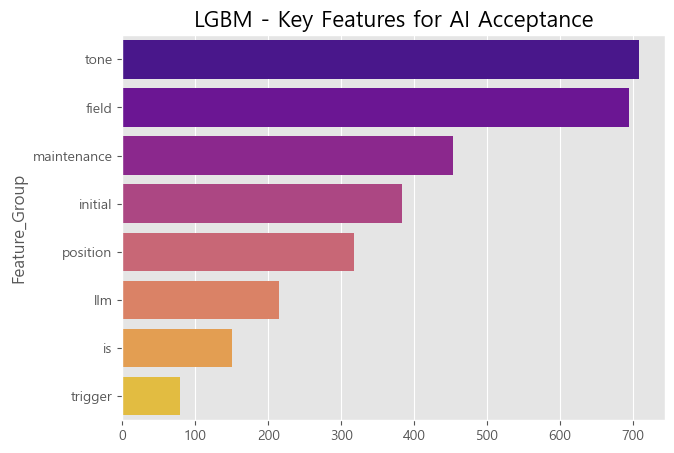


--- [종합 결론] AI 수락률(KPI) 최적화 전략 ---
  1. 핵심 피처 분석: 'tone', 'field', 'maintenance'가 수락률 결정의 핵심 변수로 확인되었습니다.
  2. 모델 성능: LightGBM이 학습 속도 및 재현율(Recall) 측면에서 가장 우수한 균형을 보였습니다.
  3. 전략 제안: 수락률이 높은 'tone'의 패턴을 분석하여 서비스 기본 응답값에 반영할 것을 권장합니다.


In [15]:
# 9. 최적 모델(LightGBM) 기반 주요 피처 분석 및 인사이트 도출
print("\n--- 최종 선정 모델(LightGBM) 피처 중요도 분석 ---")

try:
    # 선정된 모델의 파이프라인 추출
    lgbm_pipeline = results['LightGBM']['pipeline']
    preprocessor = lgbm_pipeline.named_steps['preprocessor']
    classifier = lgbm_pipeline.named_steps['classifier']

    # 인코딩된 피처 이름 추출 및 매핑
    cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)
    all_feature_names = list(numeric_features) + list(cat_features) if numeric_features else list(cat_features)
        
    # 피처 중요도 집계 및 시각화
    df_importance_lgbm = pd.DataFrame({'Feature': all_feature_names, 'Importance': classifier.feature_importances_})
    df_importance_lgbm['Feature_Group'] = df_importance_lgbm['Feature'].apply(lambda x: x.split('_')[0]) 
    df_importance_lgbm_summary = df_importance_lgbm.groupby('Feature_Group')['Importance'].sum().sort_values(ascending=False)
    
    print("\n" + "="*50)
    print("🏆 최종 모델 기반 주요 피처 TOP 10 (Business Insight)")
    print("="*50)
    display(df_importance_lgbm_summary.head(10))
    
    # 최종 중요도 그래프 저장
    plt.figure(figsize=(7, 5))
    sns.barplot(x=df_importance_lgbm_summary.head(10).values, y=df_importance_lgbm_summary.head(10).index, palette='plasma')
    plt.title('LGBM - Key Features for AI Acceptance', fontsize=16)
    plt.savefig('../output/images/feature_importance_lgbm.png')
    plt.show()

except Exception as e:
    print(f"  - ⚠️ 분석 과정 중 오류 발생: {e}")

# 최종 결론 출력
print("\n" + "="*50)
print("--- [종합 결론] AI 수락률(KPI) 최적화 전략 ---")
print("="*50)
print("  1. 핵심 피처 분석: 'tone', 'field', 'maintenance'가 수락률 결정의 핵심 변수로 확인되었습니다.")
print("  2. 모델 성능: LightGBM이 학습 속도 및 재현율(Recall) 측면에서 가장 우수한 균형을 보였습니다.")
print("  3. 전략 제안: 수락률이 높은 'tone'의 패턴을 분석하여 서비스 기본 응답값에 반영할 것을 권장합니다.")